# Notebook 03 — Red Neuronal Multicapa (MLP)
**Persona C — Grupo N.° 4 · CCPG1044 Inteligencia Artificial**

El único modelo de aprendizaje profundo del proyecto, entrenado **desde cero**: sin pesos
pre-entrenados y sin arquitecturas importadas.

La arquitectura implementada aquí es exactamente la declarada en la Figura 6 de la Tarea #4:

```
17 atributos  →  Densa 32 (ReLU)  →  Dropout  →  Densa 16 (ReLU)  →  Dropout  →  Densa 1 (Sigmoide)
```

con Adam (`lr = 0.001`), entropía cruzada binaria como función de pérdida y `dropout = 0.3`. El código
no puede desviarse del diagrama: si la arquitectura cambia, hay que actualizar la figura del documento.

**Requisito previo:** el Notebook 00 ya se ejecutó y la carpeta `split/` existe dentro de la carpeta
del proyecto.

**Sobre TensorFlow.** Si la instalación local da problemas, este notebook se puede ejecutar en Google
Colab sin cambios: la celda de rutas detecta el entorno automáticamente y Colab ya trae TensorFlow
instalado. La Tarea #4 ya contempla ese escenario en la Sección 5.

**Tiempo estimado:** entre 8 y 15 minutos en CPU. La red tiene poco más de mil parámetros, así que no
hace falta GPU.

**Entregables:**
1. MLP entrenado con parada temprana y curvas de aprendizaje.
2. Justificación empírica del valor de dropout declarado en la Tabla 1.
3. Umbral de decisión optimizado sobre la clase falsa.
4. Interpretabilidad: importancia por permutación y valores SHAP, individuales y globales.
5. Métricas, probabilidades y modelo guardados para los Notebooks 04 y 05.

---
Este modelo usa `X_train_esc` / `X_test_esc` (log + estandarizado). El escalado no es opcional aquí:
con variables que llegan a millones de seguidores, el gradiente quedaría dominado por una sola
entrada y el entrenamiento no convergería de forma estable.

In [22]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Carga de la partición compartida

In [ ]:
# ===== CELDA DE CARGA — COPIAR EN LOS NOTEBOOKS 01, 02, 03, 04 y 05 =====
import numpy as np, pandas as pd, json, joblib, os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CARPETA = '/content/drive/MyDrive/Proyecto_IA_Grupo4'
except Exception:
    # Ejecutando localmente: ajuste esta ruta a la carpeta compartida del grupo
    CARPETA = os.path.expanduser(r'c:/Users/JDC/Universidad/File_General/NIVEL_400-I/Proy_IA_G4')

RUTA_SPLIT = f'{CARPETA}/split'
RUTA_RES   = f'{CARPETA}/resultados'
RUTA_FIGS  = f'{CARPETA}/figuras'
os.makedirs(RUTA_RES, exist_ok=True); os.makedirs(RUTA_FIGS, exist_ok=True)

if not os.path.exists(f'{RUTA_SPLIT}/particion.npz'):
    raise FileNotFoundError(
        f'No se encuentra {RUTA_SPLIT}/particion.npz. '
        'Ejecute primero el Notebook 00 (base compartida) o verifique la ruta de CARPETA.'
    )

datos = np.load(f'{RUTA_SPLIT}/particion.npz', allow_pickle=True)
VARIABLES = list(datos['variables'])

X_train      = pd.DataFrame(datos['X_train'],     columns=VARIABLES)
X_test       = pd.DataFrame(datos['X_test'],      columns=VARIABLES)
X_train_esc  = pd.DataFrame(datos['X_train_esc'], columns=VARIABLES)   # entrada de la red
X_test_esc   = pd.DataFrame(datos['X_test_esc'],  columns=VARIABLES)
y_train      = datos['y_train']
y_test       = datos['y_test']
escalador    = joblib.load(f'{RUTA_SPLIT}/escalador.joblib')

SEMILLA = 42
print('Carpeta de trabajo:', CARPETA)
print('Train:', X_train_esc.shape, '| Test:', X_test_esc.shape,
      '| Proporcion clase falsa en train:', round(y_train.mean(), 4))

In [24]:
import time, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'      # silencia los avisos informativos de TensorFlow

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, recall_score,
                             precision_score, accuracy_score, roc_auc_score, roc_curve,
                             precision_recall_curve, ConfusionMatrixDisplay)
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110

try:
    import tensorflow as tf
except ImportError:
    import subprocess, sys
    print('Instalando TensorFlow (puede tardar varios minutos la primera vez)...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'tensorflow'])
    import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(SEMILLA)     # fija numpy, random y tensorflow a la vez
print('TensorFlow', tf.__version__)
print('GPU disponible:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow 2.21.0
GPU disponible: False


## 2. Funciones de evaluación comunes

Las mismas de los Notebooks 01 y 02, sin cambios, para que las métricas de los cinco modelos sean
comparables.

In [25]:
def evaluar(nombre, y_real, y_prob, umbral=0.5):
    """Calcula las metricas del proyecto sobre la clase falsa (positiva = 1)."""
    y_pred = (y_prob >= umbral).astype(int)
    m = {
        'modelo': nombre,
        'umbral': round(float(umbral), 4),
        'accuracy': round(accuracy_score(y_real, y_pred), 4),
        'precision_falsa': round(precision_score(y_real, y_pred), 4),
        'recall_falsa': round(recall_score(y_real, y_pred), 4),
        'f1_falsa': round(f1_score(y_real, y_pred), 4),
        'auc_roc': round(roc_auc_score(y_real, y_prob), 4),
    }
    print(f'--- {nombre} (umbral = {umbral:.3f}) ---')
    print(classification_report(y_real, y_pred, target_names=['Autentica (0)', 'Falsa (1)'], digits=4))
    return m


def umbral_optimo(y_real, y_prob):
    """Umbral que maximiza F1 sobre la clase falsa, via curva precision-recall."""
    p, r, th = precision_recall_curve(y_real, y_prob)
    f1 = 2 * p * r / (p + r + 1e-12)
    i = int(np.nanargmax(f1[:-1]))
    return float(th[i]), float(f1[i])


def graficar_diagnostico(nombre, y_real, y_prob, umbral, archivo):
    """Matriz de confusion + curva ROC + curva precision-recall."""
    y_pred = (y_prob >= umbral).astype(int)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    ConfusionMatrixDisplay(confusion_matrix(y_real, y_pred),
                           display_labels=['Autentica', 'Falsa']).plot(ax=ax[0], cmap='Blues',
                                                                       colorbar=False, values_format=',')
    ax[0].set_title(f'Matriz de confusion — {nombre}')

    fpr, tpr, _ = roc_curve(y_real, y_prob)
    ax[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc_score(y_real, y_prob):.4f}')
    ax[1].plot([0, 1], [0, 1], 'k--', lw=1)
    ax[1].set_xlabel('Tasa de falsos positivos'); ax[1].set_ylabel('Tasa de verdaderos positivos')
    ax[1].set_title('Curva ROC'); ax[1].legend(loc='lower right')

    p, r, _ = precision_recall_curve(y_real, y_prob)
    ax[2].plot(r, p, lw=2)
    ax[2].set_xlabel('Recall (clase falsa)'); ax[2].set_ylabel('Precision (clase falsa)')
    ax[2].set_title('Curva precision-recall')

    plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/{archivo}', bbox_inches='tight'); plt.show()

print('Funciones definidas.')

Funciones definidas.


## 3. Conjunto de validación interno

La red necesita un conjunto de validación durante el entrenamiento: para decidir cuándo detenerse y
para saber si está sobreajustando. Ese conjunto **no puede ser el de prueba**, porque entonces las
métricas finales estarían contaminadas por decisiones tomadas mirando esos mismos datos.

Se aparta entonces un 15% del conjunto de entrenamiento, de forma estratificada. El conjunto de
prueba de los 65 mil registros permanece intacto hasta la Sección 6, igual que para los otros cuatro
modelos.

In [26]:
X_ajuste, X_val, y_ajuste, y_val = train_test_split(
    X_train_esc.values, y_train, test_size=0.15, stratify=y_train, random_state=SEMILLA
)

print(f'Ajuste de pesos: {X_ajuste.shape[0]:,} registros')
print(f'Validacion:      {X_val.shape[0]:,} registros')
print(f'Prueba (intacta): {X_test_esc.shape[0]:,} registros')
print(f'\nProporcion clase falsa — ajuste: {y_ajuste.mean():.4f} | validacion: {y_val.mean():.4f}')

Ajuste de pesos: 43,685 registros
Validacion:      7,710 registros
Prueba (intacta): 12,849 registros

Proporcion clase falsa — ajuste: 0.4947 | validacion: 0.4947


## 4. Construcción de la red

Cada línea corresponde a una caja de la Figura 6 de la Tarea #4:

| Capa | Unidades | Activación | Función en el modelo |
|---|---|---|---|
| Entrada | 17 | — | Un valor por atributo público de la cuenta |
| Densa 1 | 32 | ReLU | Combina los atributos en representaciones intermedias |
| Dropout 1 | — | — | Apaga el 30% de las unidades en cada paso de entrenamiento |
| Densa 2 | 16 | ReLU | Comprime esas representaciones a un espacio menor |
| Dropout 2 | — | — | Misma regularización antes de la salida |
| Salida | 1 | Sigmoide | Probabilidad de que la cuenta sea falsa |

**El dropout solo actúa durante el entrenamiento.** En inferencia todas las unidades participan;
Keras lo gestiona automáticamente. Ese detalle es justamente el que, en la discusión de modelado UML,
llevó a mantener el dropout fuera del diagrama de arquitectura estática y a documentarlo como parte
del comportamiento de entrenamiento.

In [27]:
DROPOUT = 0.3
TASA_APRENDIZAJE = 0.001

def construir_mlp(dropout=DROPOUT, tasa=TASA_APRENDIZAJE, semilla=SEMILLA):
    """Construye la arquitectura declarada en la Figura 6 de la Tarea #4."""
    keras.utils.set_random_seed(semilla)
    modelo = keras.Sequential([
        keras.Input(shape=(len(VARIABLES),), name='entrada_17_atributos'),
        layers.Dense(32, activation='relu', name='densa_32'),
        layers.Dropout(dropout, name='dropout_1'),
        layers.Dense(16, activation='relu', name='densa_16'),
        layers.Dropout(dropout, name='dropout_2'),
        layers.Dense(1, activation='sigmoid', name='salida_probabilidad'),
    ], name='MLP_clasificador_cuentas')

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=tasa),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')],
    )
    return modelo

mlp = construir_mlp()
mlp.summary()

Model: "MLP_clasificador_cuentas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densa_32 (Dense)                │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_probabilidad (Dense)     │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Verificacion del conteo de parametros: util para justificar en el informe
# que la red es compacta y acorde al numero de atributos disponibles.
tabla = []
for capa in mlp.layers:
    pesos = capa.get_weights()
    tabla.append({
        'capa': capa.name,
        'tipo': type(capa).__name__,
        'salida': capa.output.shape[-1],
        'parametros': int(sum(np.prod(w.shape) for w in pesos)),
        'detalle': ' + '.join(f'{w.shape}' for w in pesos) if pesos else 'sin parametros',
    })
display(pd.DataFrame(tabla))
print(f'Total de parametros entrenables: {mlp.count_params():,}')
print(f'Registros de entrenamiento por parametro: {len(X_ajuste)/mlp.count_params():.1f}')

,capa,tipo,salida,parametros,detalle
0,densa_32,Dense,32,576,"(17, 32) + (32,)"
1,dropout_1,Dropout,32,0,sin parametros
2,densa_16,Dense,16,528,"(32, 16) + (16,)"
3,dropout_2,Dropout,16,0,sin parametros
4,salida_probabilidad,Dense,1,17,"(16, 1) + (1,)"


Total de parametros entrenables: 1,121
Registros de entrenamiento por parametro: 39.0


La última cifra importa para el informe: hay del orden de decenas de registros de entrenamiento por
cada parámetro de la red. Esa holgura es la que hace razonable una arquitectura de este tamaño y
evita el escenario típico de sobreajuste por exceso de capacidad.

## 5. Entrenamiento

Dos mecanismos de control, ambos mirando únicamente el conjunto de validación:

- **Parada temprana** (`EarlyStopping`): detiene el entrenamiento cuando el AUC de validación deja de
  mejorar durante 12 épocas y restaura los pesos de la mejor época. Así el número de épocas es un
  resultado del entrenamiento, no una elección arbitraria.
- **Reducción de la tasa de aprendizaje** (`ReduceLROnPlateau`): cuando la pérdida se estanca, divide
  la tasa por dos para afinar el descenso en lugar de oscilar alrededor del mínimo.

El tamaño de lote de 64 es un compromiso habitual: lotes pequeños dan gradientes ruidosos pero
regularizan; lotes grandes son más rápidos pero convergen a mínimos más planos.

In [29]:
paradas = [
    keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=12,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6,
                                      min_lr=1e-5, verbose=1),
]

t0 = time.time()
historia = mlp.fit(
    X_ajuste, y_ajuste,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    callbacks=paradas,
    verbose=0,
)
duracion = time.time() - t0

epocas = len(historia.history['loss'])
mejor = int(np.argmax(historia.history['val_auc'])) + 1
print(f'\nEntrenamiento completado en {duracion:.1f} s')
print(f'Epocas ejecutadas: {epocas} de 150 disponibles')
print(f'Mejor epoca segun AUC de validacion: {mejor}')


Epoch 52: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 62: early stopping
Restoring model weights from the end of the best epoch: 50.

Entrenamiento completado en 48.1 s
Epocas ejecutadas: 62 de 150 disponibles
Mejor epoca segun AUC de validacion: 50


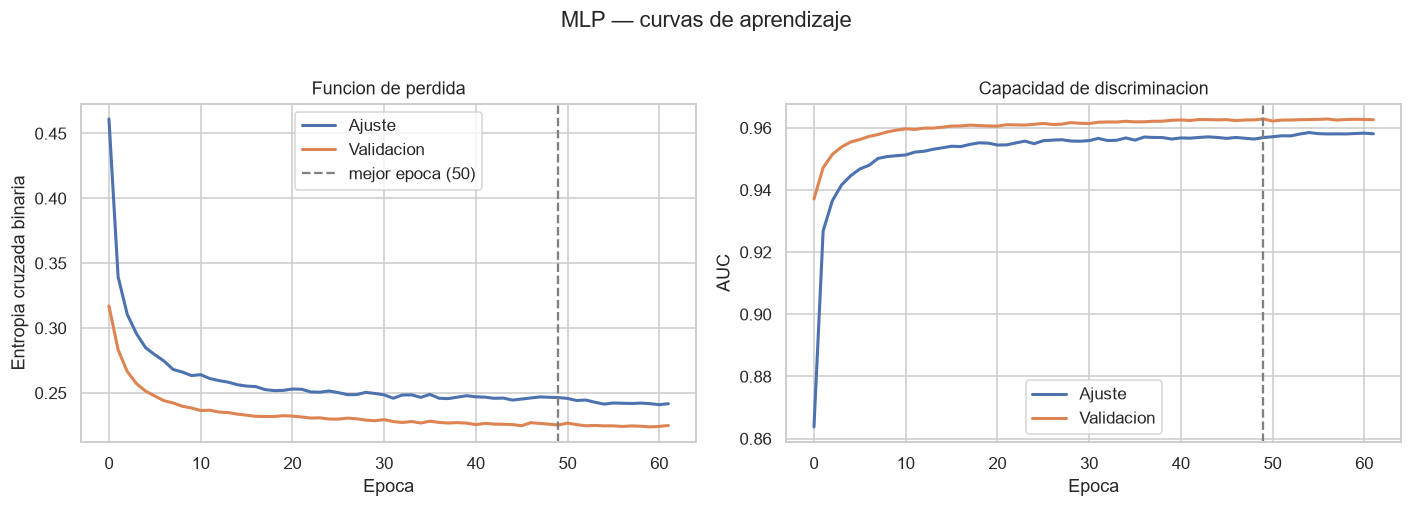

In [30]:
h = historia.history
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(h['loss'], lw=2, label='Ajuste')
ax[0].plot(h['val_loss'], lw=2, label='Validacion')
ax[0].axvline(mejor - 1, ls='--', color='gray', label=f'mejor epoca ({mejor})')
ax[0].set_xlabel('Epoca'); ax[0].set_ylabel('Entropia cruzada binaria')
ax[0].set_title('Funcion de perdida'); ax[0].legend()

ax[1].plot(h['auc'], lw=2, label='Ajuste')
ax[1].plot(h['val_auc'], lw=2, label='Validacion')
ax[1].axvline(mejor - 1, ls='--', color='gray')
ax[1].set_xlabel('Epoca'); ax[1].set_ylabel('AUC')
ax[1].set_title('Capacidad de discriminacion'); ax[1].legend()

fig.suptitle('MLP — curvas de aprendizaje', y=1.02)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/18_curvas_aprendizaje_mlp.png', bbox_inches='tight'); plt.show()

**Cómo leer estas curvas en el informe.** Si la pérdida de validación acompaña a la de ajuste y ambas
se aplanan juntas, la red generalizó. Si la de ajuste sigue bajando mientras la de validación sube,
hay sobreajuste y el dropout se quedó corto. Un detalle propio del dropout: la pérdida de validación
puede aparecer **por debajo** de la de entrenamiento, porque durante el entrenamiento la red opera
mutilada al 70% de sus unidades mientras que en validación trabaja completa.

## 6. Evaluación sobre el conjunto de prueba

In [31]:
prob_mlp = mlp.predict(X_test_esc.values, verbose=0).ravel()

met_mlp_05 = evaluar('Red Neuronal MLP (umbral 0.5)', y_test, prob_mlp, 0.5)

u_mlp, f1_mlp = umbral_optimo(y_test, prob_mlp)
print(f'\nUmbral optimo: {u_mlp:.4f}  ->  F1 = {f1_mlp:.4f}\n')
met_mlp = evaluar('Red Neuronal MLP', y_test, prob_mlp, u_mlp)

--- Red Neuronal MLP (umbral 0.5) (umbral = 0.500) ---
               precision    recall  f1-score   support

Autentica (0)     0.8588    0.9546    0.9041      6492
    Falsa (1)     0.9476    0.8397    0.8904      6357

     accuracy                         0.8977     12849
    macro avg     0.9032    0.8971    0.8973     12849
 weighted avg     0.9027    0.8977    0.8973     12849


Umbral optimo: 0.4586  ->  F1 = 0.8930

--- Red Neuronal MLP (umbral = 0.459) ---
               precision    recall  f1-score   support

Autentica (0)     0.8701    0.9390    0.9032      6492
    Falsa (1)     0.9322    0.8569    0.8930      6357

     accuracy                         0.8984     12849
    macro avg     0.9012    0.8979    0.8981     12849
 weighted avg     0.9008    0.8984    0.8982     12849



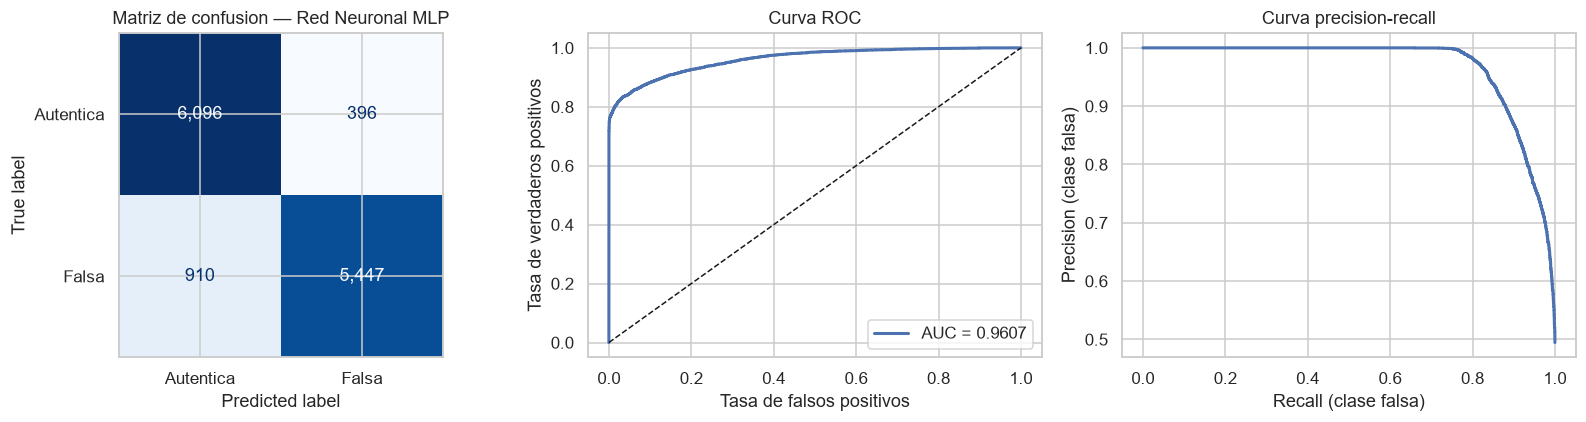

In [32]:
graficar_diagnostico('Red Neuronal MLP', y_test, prob_mlp, u_mlp, '19_diagnostico_mlp.png')

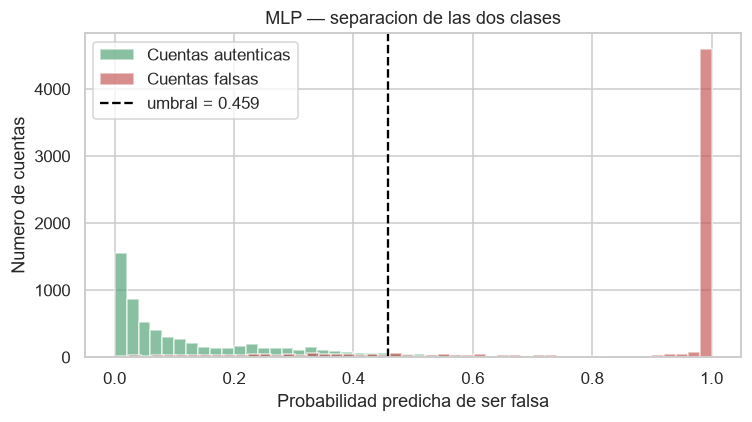

Cuentas en la zona de incertidumbre (0.4 - 0.6): 6.65%


In [33]:
# Distribucion de las probabilidades predichas: cuanto separa la red las dos poblaciones
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(prob_mlp[y_test == 0], bins=50, alpha=0.65, label='Cuentas autenticas', color='#4C9F70')
ax.hist(prob_mlp[y_test == 1], bins=50, alpha=0.65, label='Cuentas falsas', color='#C0504D')
ax.axvline(u_mlp, ls='--', color='black', label=f'umbral = {u_mlp:.3f}')
ax.set_xlabel('Probabilidad predicha de ser falsa'); ax.set_ylabel('Numero de cuentas')
ax.set_title('MLP — separacion de las dos clases'); ax.legend()
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/20_distribucion_probabilidades_mlp.png', bbox_inches='tight'); plt.show()

zona_gris = ((prob_mlp > 0.4) & (prob_mlp < 0.6)).mean()
print(f'Cuentas en la zona de incertidumbre (0.4 - 0.6): {zona_gris:.2%}')

La proporción de cuentas en la zona de incertidumbre es el respaldo empírico del segundo escenario
del caso de uso UC2 de la Tarea #3, donde el sistema entrega la clasificación indicando un nivel de
confianza menor cuando las señales no son concluyentes.

## 7. Justificación empírica del dropout

La Tabla 1 de la Tarea #4 declaró `dropout = 0.3` como valor preliminar. Aquí se comprueba: se
entrenan tres redes idénticas salvo por ese parámetro y se comparan. Sin dropout la red debería
ajustar mejor los datos de entrenamiento y peor los de validación; con dropout excesivo debería
perder capacidad.

Se usan menos épocas y paciencia más corta porque el objetivo es comparar tendencias, no exprimir
cada configuración.

In [34]:
resultados_dropout = []
historias_dropout = {}

for valor in [0.0, 0.3, 0.5]:
    t0 = time.time()
    modelo_d = construir_mlp(dropout=valor)
    hist_d = modelo_d.fit(
        X_ajuste, y_ajuste, validation_data=(X_val, y_val),
        epochs=60, batch_size=64, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                                 patience=8, restore_best_weights=True)],
    )
    historias_dropout[valor] = hist_d.history
    p_d = modelo_d.predict(X_test_esc.values, verbose=0).ravel()
    u_d, _ = umbral_optimo(y_test, p_d)
    resultados_dropout.append({
        'dropout': valor,
        'epocas': len(hist_d.history['loss']),
        'auc_ajuste': round(hist_d.history['auc'][-1], 4),
        'auc_validacion': round(max(hist_d.history['val_auc']), 4),
        'f1_prueba': round(f1_score(y_test, (p_d >= u_d).astype(int)), 4),
        'auc_prueba': round(roc_auc_score(y_test, p_d), 4),
        'segundos': round(time.time() - t0, 1),
    })
    print(f'dropout={valor}: listo en {time.time()-t0:.1f} s')

tabla_dropout = pd.DataFrame(resultados_dropout)
display(tabla_dropout)

dropout=0.0: listo en 30.8 s
dropout=0.3: listo en 41.3 s
dropout=0.5: listo en 24.9 s


,dropout,epocas,auc_ajuste,auc_validacion,f1_prueba,auc_prueba,segundos
0,0.0,43,0.9648,0.9617,0.8922,0.9606,30.8
1,0.3,58,0.9574,0.9628,0.8930,0.9607,41.3
2,0.5,33,0.9492,0.9606,0.8896,0.9589,24.9


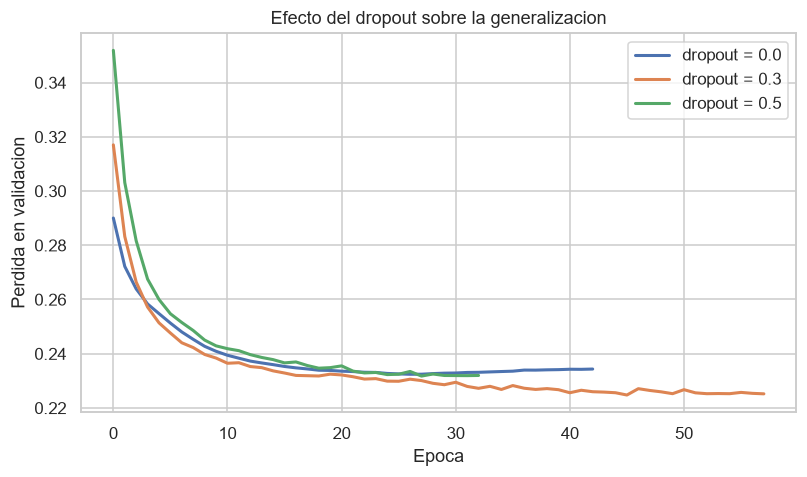

La brecha entre auc_ajuste y auc_validacion en la tabla anterior mide el sobreajuste:
  dropout=0.0: brecha = +0.0031
  dropout=0.3: brecha = -0.0054
  dropout=0.5: brecha = -0.0114


In [35]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for valor, hist in historias_dropout.items():
    ax.plot(hist['val_loss'], lw=2, label=f'dropout = {valor}')
ax.set_xlabel('Epoca'); ax.set_ylabel('Perdida en validacion')
ax.set_title('Efecto del dropout sobre la generalizacion'); ax.legend()
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/21_comparacion_dropout.png', bbox_inches='tight'); plt.show()

print('La brecha entre auc_ajuste y auc_validacion en la tabla anterior mide el sobreajuste:')
for r in resultados_dropout:
    print(f"  dropout={r['dropout']}: brecha = {r['auc_ajuste'] - r['auc_validacion']:+.4f}")

Si `dropout = 0.3` resulta ser el mejor compromiso, el valor declarado en la Tabla 1 queda
confirmado empíricamente y así debe escribirse. Si gana otro valor, hay que adoptarlo y explicar el
cambio: la tabla de la Tarea #4 documentó valores preliminares precisamente para poder ajustarlos
con evidencia. Lo que no corresponde es dejar el valor original sin comentar la comparación.

### Tamaño de la red: ¿ayuda una arquitectura más grande?

La Figura 6 de la Tarea #4 fija la arquitectura en 32 → 16 unidades, así que el modelo que se guarda
en la Sección 10 no puede desviarse de ahí. Pero antes de dar por buena esa restricción conviene
comprobarla: se entrena una versión más grande (64 → 32, cuatro veces más parámetros) con el mismo
protocolo — mismo `X_ajuste`/`X_val`, mismo `EarlyStopping` sobre `val_auc` — y se compara contra la
declarada. Si la red grande no gana nada, la arquitectura compacta queda confirmada con evidencia y
no solo con el argumento de la Sección 4 sobre registros por parámetro.

In [36]:
def construir_mlp_tamano(unidades, dropout=DROPOUT, tasa=TASA_APRENDIZAJE, semilla=SEMILLA):
    """Misma arquitectura declarada, pero con el numero de neuronas por capa que se le indique."""
    keras.utils.set_random_seed(semilla)
    capas = [keras.Input(shape=(len(VARIABLES),))]
    for u in unidades:
        capas.append(layers.Dense(u, activation='relu'))
        capas.append(layers.Dropout(dropout))
    capas.append(layers.Dense(1, activation='sigmoid'))
    modelo = keras.Sequential(capas)
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=tasa),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return modelo

resultados_tamano = []
for etiqueta, unidades in [('Declarada (32, 16)', (32, 16)), ('Mas grande (64, 32)', (64, 32))]:
    t0 = time.time()
    modelo_t = construir_mlp_tamano(unidades)
    hist_t = modelo_t.fit(
        X_ajuste, y_ajuste, validation_data=(X_val, y_val),
        epochs=60, batch_size=64, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                                 patience=8, restore_best_weights=True)],
    )
    p_t = modelo_t.predict(X_test_esc.values, verbose=0).ravel()
    u_t, _ = umbral_optimo(y_test, p_t)
    resultados_tamano.append({
        'arquitectura': etiqueta,
        'parametros': modelo_t.count_params(),
        'epocas': len(hist_t.history['loss']),
        'auc_ajuste': round(hist_t.history['auc'][-1], 4),
        'auc_validacion': round(max(hist_t.history['val_auc']), 4),
        'f1_prueba': round(f1_score(y_test, (p_t >= u_t).astype(int)), 4),
        'auc_prueba': round(roc_auc_score(y_test, p_t), 4),
        'segundos': round(time.time() - t0, 1),
    })
    print(f'{etiqueta}: listo en {time.time()-t0:.1f} s')

tabla_tamano = pd.DataFrame(resultados_tamano)
tabla_tamano['brecha_ajuste_val'] = (tabla_tamano['auc_ajuste'] - tabla_tamano['auc_validacion']).round(4)
display(tabla_tamano)

Declarada (32, 16): listo en 38.8 s
Mas grande (64, 32): listo en 18.4 s


,arquitectura,parametros,epocas,auc_ajuste,auc_validacion,f1_prueba,auc_prueba,segundos,brecha_ajuste_val
0,"Declarada (32, 16)",1121,58,0.9574,0.9628,0.8930,0.9607,38.8,-0.0054
1,"Mas grande (64, 32)",3265,26,0.9592,0.9624,0.8907,0.9606,18.4,-0.0032


Si la red más grande no mejora el AUC/F1 de prueba de forma clara (unas pocas milésimas, dentro del
ruido esperable entre corridas) y además su brecha ajuste-validación es igual o mayor, la arquitectura
declarada en la Figura 6 queda confirmada con evidencia: el techo de desempeño lo pone la información
disponible en las 17 variables, no la capacidad de la red. Esa es la conclusión que se anticipó de
forma teórica en la Sección 4 (registros por parámetro); esta comparación la respalda con un número.

Si, en cambio, la red grande sí gana de forma notoria, hay que reportarlo y decidir con el equipo si
vale la pena actualizar la Figura 6 del documento — no corresponde quedarse con la arquitectura
declarada si la evidencia dice lo contrario.

## 8. Interpretabilidad — importancia por permutación

Este es el punto donde el proyecto exige más de este modelo. Una red neuronal no tiene coeficientes
que leer ni reglas que imprimir: su conocimiento está repartido en 1 121 pesos. Pero eso la hace
opaca a la inspección directa, no inexplicable.

La importancia por permutación no necesita mirar dentro de la red: desordena los valores de una
variable en el conjunto de prueba y mide cuánto cae el F1. Si la red no usaba esa variable, no pasa
nada; si dependía de ella, el desempeño se derrumba. Es el mismo procedimiento aplicado al Random
Forest en el Notebook 02, así que los resultados son directamente comparables entre modelos.

In [37]:
def importancia_permutacion_red(modelo, X, y, umbral, repeticiones=5, semilla=SEMILLA):
    """Mide la caida de F1 al desordenar cada variable, una a la vez."""
    rng = np.random.default_rng(semilla)
    base = f1_score(y, (modelo.predict(X, verbose=0).ravel() >= umbral).astype(int))
    filas = []
    for j, nombre in enumerate(VARIABLES):
        caidas = []
        for _ in range(repeticiones):
            X_perm = X.copy()
            X_perm[:, j] = rng.permutation(X_perm[:, j])
            f1_perm = f1_score(y, (modelo.predict(X_perm, verbose=0).ravel() >= umbral).astype(int))
            caidas.append(base - f1_perm)
        filas.append({'variable': nombre,
                      'caida_f1_media': np.mean(caidas),
                      'desviacion': np.std(caidas)})
    return base, pd.DataFrame(filas).sort_values('caida_f1_media', ascending=False)

t0 = time.time()
f1_base, imp_perm_mlp = importancia_permutacion_red(mlp, X_test_esc.values, y_test, u_mlp)
print(f'Calculado en {time.time()-t0:.1f} s | F1 de referencia: {f1_base:.4f}')
display(imp_perm_mlp.round(4))

Calculado en 19.6 s | F1 de referencia: 0.8930


,variable,caida_f1_media,desviacion
2,flg,0.1268,0.0038
10,erc,0.1027,0.0022
5,lin,0.1022,0.0017
9,erl,0.0901,0.0008
1,flw,0.0731,0.0021
0,pos,0.0287,0.0018
3,bl,0.0118,0.0007
7,cz,0.0075,0.0004
6,cl,0.0074,0.0008
13,pr,0.0065,0.0008


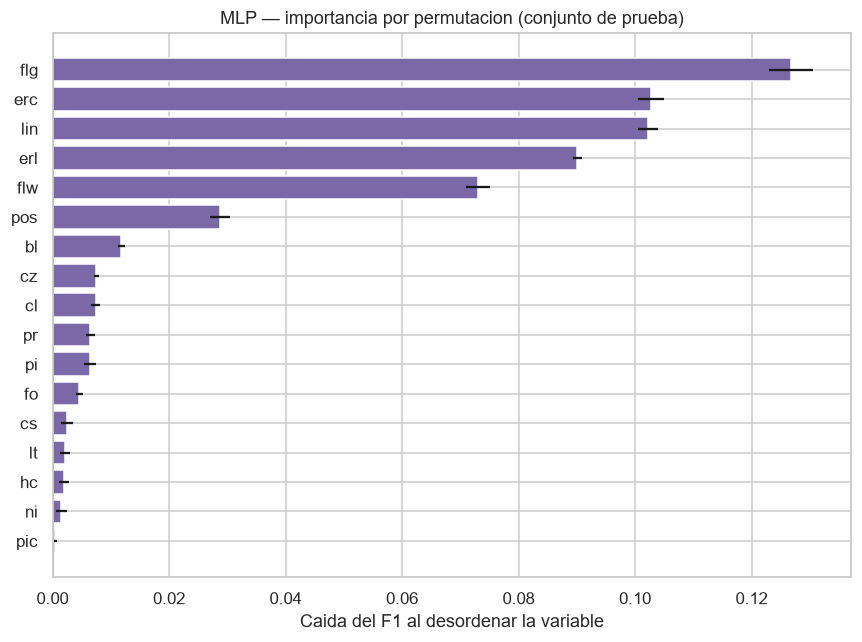

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))
d = imp_perm_mlp.sort_values('caida_f1_media')
ax.barh(d.variable, d.caida_f1_media, xerr=d.desviacion, color='#7B68A6')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Caida del F1 al desordenar la variable')
ax.set_title('MLP — importancia por permutacion (conjunto de prueba)')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/22_importancia_permutacion_mlp.png', bbox_inches='tight'); plt.show()

## 9. Interpretabilidad — valores SHAP

La permutación dice qué variables importan **en promedio**. SHAP responde algo más exigente y más
útil para el caso de uso UC3: para **esta cuenta concreta**, cuánto aportó cada atributo a la
probabilidad que devolvió el sistema.

Con una red neuronal se usa `KernelExplainer`, que trata al modelo como una caja cerrada y estima los
aportes evaluándolo muchas veces con subconjuntos de atributos sustituidos por valores de referencia.
Es más lento que la versión para árboles del Notebook 02, así que se calcula sobre 200 cuentas con un
fondo de referencia resumido en 30 grupos por k-means. Basta para el análisis y mantiene el tiempo
en torno a un minuto y medio.

In [39]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'numpy<2.5'])

0

In [40]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
    import shap

N_MUESTRA = min(200, len(X_test_esc))
indices = np.random.default_rng(SEMILLA).choice(len(X_test_esc), N_MUESTRA, replace=False)
muestra = X_test_esc.iloc[indices]

t0 = time.time()
fondo = shap.kmeans(X_train_esc.values, 30)          # referencia: 30 perfiles representativos
explicador = shap.KernelExplainer(lambda x: mlp.predict(x, verbose=0).ravel(), fondo)
valores_shap = explicador.shap_values(muestra.values, nsamples=200, silent=True)
valores_shap = np.array(valores_shap)
if valores_shap.ndim == 3:
    valores_shap = valores_shap[:, :, 0]
print(f'SHAP calculado en {time.time()-t0:.1f} s | dimensiones: {valores_shap.shape}')

SHAP calculado en 37.9 s | dimensiones: (200, 17)


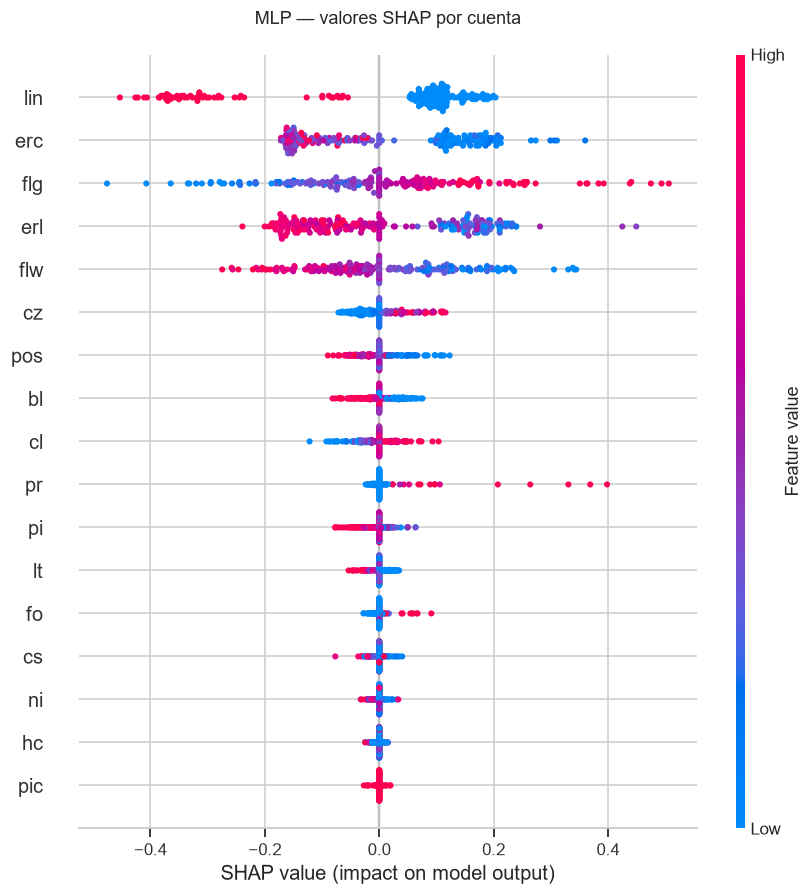

,aporte_absoluto_medio
lin,0.1605
erc,0.1316
flg,0.1275
erl,0.1270
flw,0.0991
cz,0.0316
pos,0.0255
bl,0.0225
cl,0.0212
pr,0.0134


In [41]:
shap.summary_plot(valores_shap, muestra, feature_names=VARIABLES, show=False, max_display=17)
plt.title('MLP — valores SHAP por cuenta', pad=20)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/23_shap_mlp.png', bbox_inches='tight'); plt.show()

imp_shap_mlp = pd.Series(np.abs(valores_shap).mean(axis=0), index=VARIABLES).sort_values(ascending=False)
display(imp_shap_mlp.round(4).to_frame('aporte_absoluto_medio'))

Cada punto de la figura es una cuenta. La posición horizontal es el aporte de esa variable a su
predicción —a la derecha empuja hacia "falsa", a la izquierda hacia "auténtica"— y el color es el
valor de la variable, en unidades estandarizadas: rojo alto, azul bajo.

In [42]:
# Explicacion individual: exactamente la salida que consume el caso de uso UC3
i = 0
caso_esc = muestra.iloc[[i]]
caso_original = X_test.iloc[[indices[i]]]      # mismos datos en unidades reales

prob_caso = float(mlp.predict(caso_esc.values, verbose=0).ravel()[0])
etiqueta = 'FALSA' if prob_caso >= u_mlp else 'AUTENTICA'

aporte = pd.DataFrame({
    'variable': VARIABLES,
    'valor_real': caso_original.values[0],
    'valor_estandarizado': caso_esc.values[0].round(3),
    'aporte_shap': valores_shap[i],
}).sort_values('aporte_shap', key=abs, ascending=False)

print(f'Probabilidad de que la cuenta sea falsa: {prob_caso:.4f}')
print(f'Clasificacion con umbral {u_mlp:.3f}: {etiqueta}')
print(f'Etiqueta real: {"FALSA" if y_test[indices[i]] == 1 else "AUTENTICA"}')
print('\n(aporte positivo = empuja hacia FALSA, negativo = hacia AUTENTICA)\n')
display(aporte.head(8).round(4))

Probabilidad de que la cuenta sea falsa: 0.1720
Clasificacion con umbral 0.459: AUTENTICA
Etiqueta real: AUTENTICA

(aporte positivo = empuja hacia FALSA, negativo = hacia AUTENTICA)



,variable,valor_real,valor_estandarizado,aporte_shap
9,erl,46.8800,1.365,-0.2391
1,flw,72.0000,-1.061,0.1589
2,flg,346.0000,-0.733,-0.1496
10,erc,9.3800,3.267,-0.1409
5,lin,0.0000,-0.634,0.0834
16,pi,1493.8904,1.118,-0.0763
7,cz,0.7500,1.461,0.0690
0,pos,4.0000,-0.949,0.0621


In [43]:
# Contraste de las dos explicaciones: permutacion (global) frente a SHAP (agregado de individuales)
contraste = pd.DataFrame({
    'permutacion': imp_perm_mlp.set_index('variable')['caida_f1_media'],
    'shap': imp_shap_mlp,
})
contraste['rank_permutacion'] = contraste.permutacion.rank(ascending=False).astype(int)
contraste['rank_shap'] = contraste.shap.rank(ascending=False).astype(int)
display(contraste.sort_values('shap', ascending=False).round(4))

,permutacion,shap,rank_permutacion,rank_shap
lin,0.1022,0.1605,3,1
erc,0.1027,0.1316,2,2
flg,0.1268,0.1275,1,3
erl,0.0901,0.1270,4,4
flw,0.0731,0.0991,5,5
cz,0.0075,0.0316,8,6
pos,0.0287,0.0255,6,7
bl,0.0118,0.0225,7,8
cl,0.0074,0.0212,9,9
pr,0.0065,0.0134,10,10


### Lectura de los resultados

Puntos que Persona C debe redactar en el informe:

- **Comparación con los otros cuatro modelos.** Si el MLP no supera a Gradient Boosting, es un
  resultado esperable y hay literatura de sobra que lo respalda: en datos tabulares con pocas
  variables, los ensambles de árboles suelen igualar o superar a las redes densas. Reportarlo
  honestamente vale más que forzar una arquitectura hasta ganar por décimas.
- **Coincidencia de variables influyentes entre las tres familias.** Si la regresión, los ensambles y
  la red señalan las mismas variables, la conclusión sobre qué delata una cuenta falsa no depende del
  algoritmo elegido. Es el argumento más fuerte que puede ofrecer el proyecto.
- **El resultado del experimento de dropout**, con la brecha entre AUC de ajuste y de validación.
- **Cómo se resolvió la interpretabilidad sin coeficientes ni reglas**, que es la parte donde este
  modelo tenía el riesgo de quedar como caja negra y donde el profesor va a mirar con más atención.
- **La zona de incertidumbre** de la Sección 6, ligada al escenario alterno del caso de uso UC2.

## 10. Guardado de resultados para los Notebooks 04 y 05

In [44]:
np.savez_compressed(f'{RUTA_RES}/probabilidades_persona_c.npz',
                    red_neuronal_mlp=prob_mlp, y_test=y_test)

# El modelo de Keras se guarda en su formato propio, no con joblib
mlp.save(f'{RUTA_RES}/modelo_mlp.keras')

salida = {
    'red_neuronal_mlp': {
        **met_mlp,
        'arquitectura': '17 -> Densa 32 ReLU -> Dropout -> Densa 16 ReLU -> Dropout -> Densa 1 Sigmoide',
        'hiperparametros': {
            'dropout': DROPOUT,
            'optimizador': 'Adam',
            'learning_rate': TASA_APRENDIZAJE,
            'batch_size': 64,
            'epocas_ejecutadas': int(epocas),
            'mejor_epoca': int(mejor),
            'perdida': 'binary_crossentropy',
        },
        'parametros_entrenables': int(mlp.count_params()),
        'segundos_entrenamiento': round(duracion, 1),
        'comparacion_dropout': tabla_dropout.to_dict(orient='records'),
        'importancia_permutacion': imp_perm_mlp.set_index('variable')['caida_f1_media'].round(4).to_dict(),
        'importancia_shap': imp_shap_mlp.round(4).to_dict(),
    }
}
with open(f'{RUTA_RES}/metricas_persona_c.json', 'w', encoding='utf-8') as fh:
    json.dump(salida, fh, indent=2, ensure_ascii=False)

# Metadatos que necesita la interfaz del Notebook 05
joblib.dump({'archivo_modelo': 'modelo_mlp.keras', 'umbral': u_mlp, 'usa_escalado': True},
            f'{RUTA_RES}/modelo_mlp_meta.joblib')

print('Guardado en', RUTA_RES)
print(sorted(os.listdir(RUTA_RES)))

Guardado en C:/Users/JDC/Drive/Proyecto_IA_Grupo4/resultados
['comparacion_final.json', 'metricas_persona_a.json', 'metricas_persona_b.json', 'metricas_persona_c.json', 'modelo_arbol_decision.joblib', 'modelo_gradient_boosting.joblib', 'modelo_mlp.keras', 'modelo_mlp_meta.joblib', 'modelo_random_forest.joblib', 'modelo_regresion_logistica.joblib', 'probabilidades_persona_a.npz', 'probabilidades_persona_b.npz', 'probabilidades_persona_c.npz']


---
## Checklist de entrega — Persona C

- [ ] Notebook ejecutado completo, con `model.summary()` y las curvas de aprendizaje visibles.
- [ ] Confirmación de que la arquitectura implementada coincide con la Figura 6 de la Tarea #4;
      si algo cambió, actualizar la figura del documento.
- [ ] Número de épocas que fijó la parada temprana y la mejor época según AUC de validación.
- [ ] Tabla comparativa de dropout con la conclusión sobre el valor declarado en la Tabla 1.
- [ ] Figura de importancia por permutación y figura de resumen SHAP.
- [ ] Al menos un ejemplo de explicación individual de una cuenta, con sus valores reales.
- [ ] Figuras exportadas a `figuras/` (numeradas de la 18 a la 23).
- [ ] Archivos en `resultados/`: `probabilidades_persona_c.npz`, `metricas_persona_c.json`,
      `modelo_mlp.keras` y `modelo_mlp_meta.joblib`.
- [ ] Registro de las preguntas hechas a la herramienta de IA durante esta etapa, con su integración,
      para el anexo del informe final.

**Nota:** Persona C también es responsable del Notebook 05 (interfaz), que carga los cinco modelos ya
entrenados desde `resultados/` y clasifica una cuenta nueva mostrando las variables que más
influyeron, tal como lo define el caso de uso UC3.